<a href="https://colab.research.google.com/github/anu-v-nair/executive_program_in_advanced_ai_ml_iit_palakkad/blob/main/StatisticsAssignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Statistics Assignment

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [91]:
df = pd.read_csv("StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group C,some high school,free/reduced,none,0,17,10
1,female,group B,high school,free/reduced,none,8,24,23
2,female,group B,some high school,free/reduced,none,18,32,28
3,female,group B,some college,standard,none,11,38,32
4,female,group C,some college,free/reduced,none,22,39,33


In [17]:
df.dtypes

,0
gender,object
race/ethnicity,object
parental level of education,object
lunch,object
test preparation course,object
math score,int64
reading score,int64
writing score,int64


In [18]:
df.isna().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


1. Calculate the mean, median, and mode for the math, reading, and writing scores.

In [19]:
cols = ['math score','reading score','writing score']
for col in cols:
  print(df[col].mean())

66.001
69.195
68.119


In [20]:
for col in cols:
  print(df[col].median())

66.0
70.0
69.0


In [21]:
for col in cols:
  print(df[col].mode()[0])

65
72
74


2. Determine the range, variance, and standard deviation for each score category.

In [22]:
for col in cols:
  print(df[col].max()-df[col].min())

100
83
90


In [23]:
for col in cols:
  print(df[col].var())

242.4114104104103
216.27925425425406
231.8426816816816


In [24]:
for col in cols:
  print(df[col].std())

15.569566802271998
14.7064358107005
15.226381109169756


3. Identify the mean, median, and mode of math scores for students with different
parental education levels.

In [25]:
df['parental level of education'].unique()

array(['some high school', 'high school', 'some college',
       "associate's degree", "bachelor's degree", "master's degree"],
      dtype=object)

In [26]:
df.groupby('parental level of education')['math score'].mean()

,math score
parental level of education,
associate's degree,67.977477
bachelor's degree,69.288136
high school,61.821429
master's degree,70.254237
some college,67.128319
some high school,63.134078


In [27]:
df.groupby('parental level of education')['math score'].median()

,math score
parental level of education,
associate's degree,67.0
bachelor's degree,68.0
high school,63.0
master's degree,73.0
some college,68.0
some high school,65.0


In [28]:
df.groupby('parental level of education')['math score'].agg(lambda x:x.mode()[0])

,math score
parental level of education,
associate's degree,65
bachelor's degree,63
high school,57
master's degree,79
some college,69
some high school,59


4. Compare the mean scores of students who took the test preparation course versus
those who didn’t.

In [29]:
df['test preparation course'].unique()

array(['none', 'completed'], dtype=object)

In [92]:
df['average_score'] = df[cols].mean(axis=1)

In [93]:
df.groupby('test preparation course')['average_score'].mean()

,average_score
test preparation course,
completed,72.942272
none,64.888370


5. Calculate the interquartile range (IQR) for each score category.

In [32]:
Q1_math = df['math score'].quantile(0.25)
Q3_math = df['math score'].quantile(0.75)
IQR_math = Q3_math-Q1_math
IQR_math

np.float64(20.0)

In [33]:
Q1_read = df['reading score'].quantile(0.25)
Q3_read = df['reading score'].quantile(0.75)
IQR_read = Q3_read-Q1_read
IQR_read

np.float64(20.25)

In [34]:
Q1_write = df['writing score'].quantile(0.25)
Q3_write = df['writing score'].quantile(0.75)
IQR_write = Q3_write-Q1_write
IQR_write

np.float64(21.0)

6. Determine the standard deviation for math scores by lunch type (free/reduced vs.
standard).

In [35]:
df['lunch'].unique()

array(['free/reduced', 'standard'], dtype=object)

In [36]:
df.groupby('lunch')['math score'].std()

,math score
lunch,
free/reduced,15.882442
standard,13.804560


7. Find the correlation coefficient between math and reading scores, and then between
reading and writing scores.

In [37]:
df['math score'].corr(df['reading score'])

np.float64(0.8149368617648359)

In [38]:
df['reading score'].corr(df['writing score'])

np.float64(0.953178417390664)

8. Interpret the strength and direction of the correlation. What might this suggest about
the relationship between different scores?

Ans: Both correlations are strong and positive, meaning students who perform well in one subject tend to perform well in others.

9. Calculate the covariance between math and reading scores. How does it compare
with the correlation? What does it suggest?

In [39]:
df['math score'].cov(df['reading score'])

np.float64(186.59840340340335)

Ans: Positive covariance confirms that math and reading scores increase together, consistent with correlation.

10. Z-Test: Assume the national average math score is 50. Use a one-sample z-test to test
if this sample's average math score is significantly different from the national
average.

In [86]:
z = (df['math score'].mean() - 50) / (df['math score'].std() / np.sqrt(len(df)))
if abs(z) > 1.96:
  print ("Reject null hypothesis (significant difference)")
else:
  print("Fail to reject null hypothesis")

Reject null hypothesis (significant difference)


11. T-Test: Compare the reading scores between students with different lunch types
(free/reduced vs. standard) to test if there is a significant difference.

In [41]:
from scipy.stats import ttest_ind

In [42]:
df['lunch'].unique()

array(['free/reduced', 'standard'], dtype=object)

In [43]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score
0,female,group C,some high school,free/reduced,none,0,17,10,9.000000
1,female,group B,high school,free/reduced,none,8,24,23,18.333333
2,female,group B,some high school,free/reduced,none,18,32,28,26.000000
3,female,group B,some college,standard,none,11,38,32,27.000000
4,female,group C,some college,free/reduced,none,22,39,33,31.333333


In [44]:
group1 = df[df['lunch']=='free/reduced']['reading score']
group1

,reading score
0,17
1,24
2,32
4,39
5,44
...,...
967,87
970,90
977,73
981,90


In [45]:
group2 = df[df['lunch']=='standard']['reading score']
group2

,reading score
3,38
9,29
12,51
24,46
25,45
...,...
994,87
995,87
996,96
997,97


In [85]:
t_stat,p_value = ttest_ind(group1,group2)
if p_value < 0.05:
  print ("Reject null hypothesis (significant difference)")
else:
  print("Fail to reject null hypothesis")

Reject null hypothesis (significant difference)


12. F-Test: Check if the variances of math scores differ significantly between students with and without test preparation.

<Axes: xlabel='math score', ylabel='Count'>

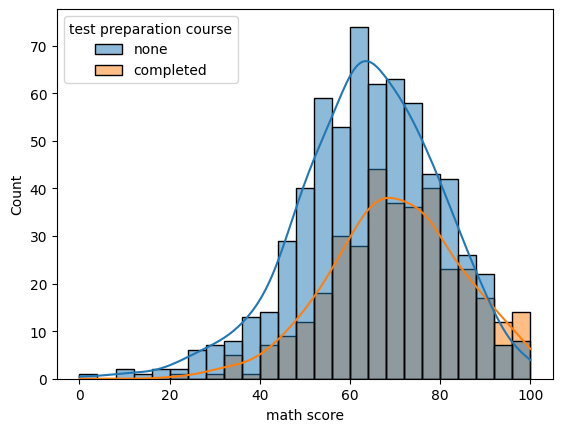

In [63]:
sns.histplot(data=df,x='math score', hue='test preparation course', kde=True)

In [48]:
df['test preparation course'].unique()

array(['none', 'completed'], dtype=object)

In [69]:
prep = df[df['test preparation course']=='completed']['math score']
prep

,math score
5,23
10,29
12,32
16,34
21,35
...,...
995,99
996,100
997,100
998,100


In [72]:
no_prep = df[df['test preparation course']=='none']['math score']
no_prep

,math score
0,0
1,8
2,18
3,11
4,22
...,...
984,94
986,94
987,95
990,97


In [65]:
from scipy import stats

In [77]:
var1 = np.var(prep,ddof=1)
var2 = np.var(no_prep,ddof=1)

210.29496582503663

In [79]:
F = var1/var2
F

0.8525402634284401

In [94]:
df1 = len(prep) - 1
df1

357

In [95]:
df2 = len(no_prep) - 1
df2

641

In [98]:
p_value = 1 - stats.f.cdf(F,df1,df2)
if p_value < 0.05:
  print ("Reject null hypothesis (significant difference)")
else:
  print("Fail to reject null hypothesis")

Fail to reject null hypothesis
